
---

# 📊 **`Tests for Normal Distribution in Statistics for Data Science`** 🔍  

## 🔹 **What is Normal Distribution?**  

✅ **Definition**: A **normal distribution (Gaussian distribution)** is a symmetrical, bell-shaped curve where most data points are concentrated around the mean.  

✅ **Why Test for Normality?**  
- ✔ Many **statistical tests (t-test, ANOVA, regression) assume normality**.  
- ✔ Helps in **choosing the right machine learning models**.  
- ✔ Detects **skewness, kurtosis, and outliers** that can impact predictions.  

📌 **Characteristics of Normal Distribution:**  
- ✔ **Mean (μ), Median, and Mode are equal**.  
- ✔ **Symmetrical shape (left & right halves are mirror images).**  
- ✔ **Follows the 68-95-99.7 Rule (Empirical Rule):**  
   - **68%** of data falls within **1 standard deviation (σ)** of the mean.  
   - **95%** of data falls within **2 standard deviations**.  
   - **99.7%** of data falls within **3 standard deviations**.  

📌 **Example Use Case**:  
- **Is customer spending normally distributed?**  
- **Do student test scores follow a normal curve?**  

---

# 🔥 **1. Methods to Test for Normality**  

| **Test Type** | **Purpose** | **Best Used For** |
|--------------|------------|------------------|
| **Visualization Methods** 📊 | Provides a graphical way to inspect normality | Small to medium datasets |
| **Statistical Tests** 📉 | Tests whether data significantly deviates from normality | Large datasets, hypothesis testing |

- ✅ **Use both graphical and statistical methods for better accuracy.**  


---

# 📊 **2. Graphical Methods for Normality Testing**  

## **📌 2.1 Histogram: Checking Shape of Data Distribution**  


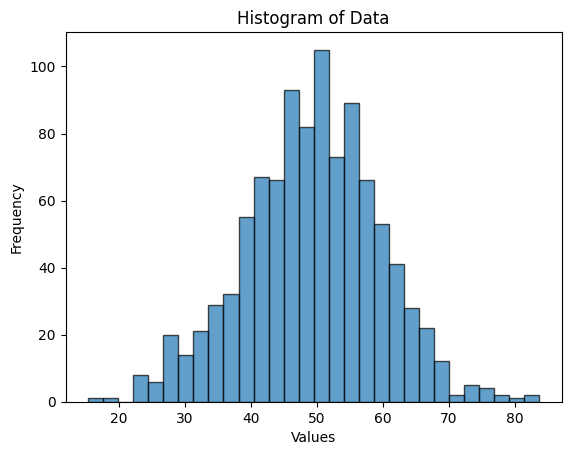

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Generate Normally Distributed Data
data = np.random.normal(loc=50, scale=10, size=1000)

# Plot Histogram
plt.hist(data, bins=30, edgecolor='black', alpha=0.7
plt.title("Histogram of Data")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()



📊 **Output**: A histogram showing **bell-shaped normal distribution**.  

✅ **Interpretation**:  
- ✔ If **symmetrical & bell-shaped**, data might be normal.  
- ✔ If **skewed (left or right)**, data is not normal.  



---

## **📌 2.2 Q-Q Plot (Quantile-Quantile Plot)**  
✅ **Purpose**: Checks if data follows a normal distribution by comparing it to a theoretical normal distribution.  


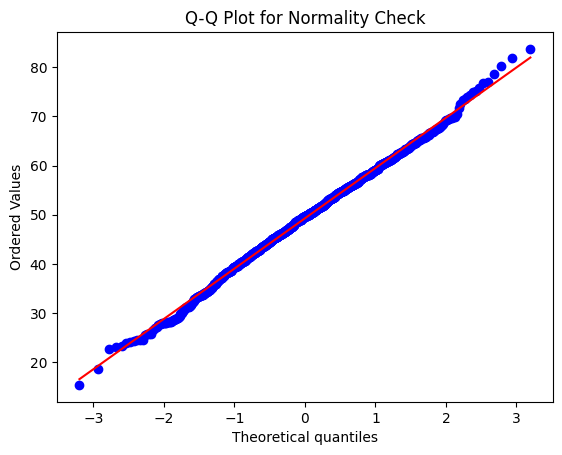

In [3]:

import scipy.stats as stats

# Q-Q Plot
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot for Normality Check")
plt.show()



📊 **Output**: A **Q-Q plot** where points **should fall along the straight line**.  

✅ **Interpretation**:  
- ✔ If **points align with the diagonal line**, data is **normally distributed**.  
- ✔ If **points deviate** (especially at the ends), data is **not normal**.  



---

## **📌 2.3 Box Plot (Detecting Skewness & Outliers)**  


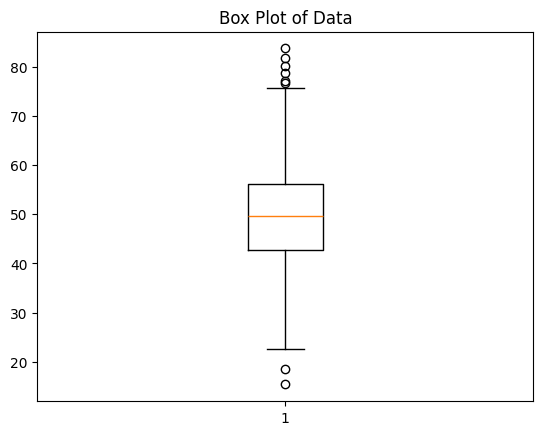

In [4]:

# Box Plot
plt.boxplot(data)
plt.title("Box Plot of Data")
plt.show()


📊 **Output**: A **box plot** showing median, quartiles, and outliers.  

✅ **Interpretation**:  
- ✔ If **data is symmetric** with few outliers → **Normal Distribution** ✅.  
- ✔ If **skewed left or right with many outliers** → **Not Normal** ❌.  



---

# 📉 **3. Statistical Tests for Normality**  

| **Test Name** | **Null Hypothesis (H₀)** | **p-value Interpretation** |
|--------------|---------------------|--------------------|
| **Shapiro-Wilk Test** | Data is normally distributed | **p > 0.05** → Fail to reject H₀ (Normal) |
| **Kolmogorov-Smirnov (K-S) Test** | Data follows a normal distribution | **p > 0.05** → Fail to reject H₀ (Normal) |
| **Anderson-Darling Test** | Data follows a normal distribution | If test statistic is below critical value → Normal |
| **D’Agostino-K² Test** | Tests for skewness & kurtosis | **p > 0.05** → Normal distribution |

- ✅ **If p < 0.05 → Data is NOT normally distributed**.  



---

## **📌 3.1 Shapiro-Wilk Test (Best for Small Samples)**  

In [7]:

from scipy.stats import shapiro

# Perform Shapiro-Wilk test
stat, p = shapiro(data)

print(f"\nShapiro-Wilk Test Statistic: {stat:.3f}, \n\np-value: {p:.5f}")

if p > 0.05:
    print("\nFail to reject H₀: Data is normally distributed.")
else:
    print("\nReject H₀: Data is NOT normally distributed.")



Shapiro-Wilk Test Statistic: 0.998, 

p-value: 0.24084

Fail to reject H₀: Data is normally distributed.



📊 **Output**:  
- ✔ **p > 0.05** → Data is normal ✅.  
- ✔ **p < 0.05** → Data is not normal ❌.  

✅ **Best for**: **Small samples (n < 50)**.  
  


---

## **📌 3.2 Kolmogorov-Smirnov (K-S) Test**

In [8]:

from scipy.stats import kstest

# Perform KS Test
stat, p = kstest(data, 'norm')

print(f"\nKolmogorov-Smirnov Test Statistic: {stat:.3f}, \n\np-value: {p:.5f}")

if p > 0.05:
    print("\nFail to reject H₀: Data is normally distributed.")
else:
    print("\nReject H₀: Data is NOT normally distributed.")



Kolmogorov-Smirnov Test Statistic: 1.000, 

p-value: 0.00000

Reject H₀: Data is NOT normally distributed.



📊 **Output**: Similar interpretation as Shapiro-Wilk Test.  

- ✅ **Best for**: **Larger samples (n > 1000)**.  



---

## **📌 3.3 Anderson-Darling Test**  


In [10]:

from scipy.stats import anderson

# Perform Anderson-Darling Test
result = anderson(data)

print(f"\nAnderson-Darling Test Statistic: {result.statistic:.3f}")
for i in range(len(result.critical_values)):
    print(f"Significance Level {result.significance_level[i]}%: Critical Value = {result.critical_values[i]}")



Anderson-Darling Test Statistic: 0.565
Significance Level 15.0%: Critical Value = 0.574
Significance Level 10.0%: Critical Value = 0.653
Significance Level 5.0%: Critical Value = 0.784
Significance Level 2.5%: Critical Value = 0.914
Significance Level 1.0%: Critical Value = 1.088



📊 **Output**:  
- ✔ If **test statistic < critical value**, data is normal ✅.  
- ✔ If **test statistic > critical value**, data is not normal ❌.  

✅ **Best for**: **All sample sizes**.  



---

# 🔄 **4. When to Use Normality Tests in Data Science?**  

📌 **Business & Marketing**  
✔ **Customer spending analysis** → "Does spending follow a normal distribution?"  
✔ **Sales forecasting** → "Are sales normally distributed?"  

📌 **Machine Learning & AI**  
✔ **Feature engineering** → Some models assume normality (e.g., Linear Regression, LDA).  
✔ **Data transformation** → Apply log/square root transformations if data is not normal.  

📌 **Healthcare & Medicine**  
✔ **Blood pressure analysis** → "Is patient data normally distributed?"  
✔ **Clinical trials** → Normality ensures valid statistical comparisons.  

📌 **Finance & Economics**  
✔ **Stock return analysis** → Normality assumption in risk modeling.  
✔ **GDP growth rates** → Check distribution before economic forecasting.  




---

# 🎯 **5. Summary: How to Test for Normal Distribution**  

| **Method** | **Type** | **Best For** |
|-----------|----------|------------|
| **Histogram** 📊 | Graphical | Checking shape of data |
| **Q-Q Plot** 📈 | Graphical | Detecting deviations from normality |
| **Box Plot** 📦 | Graphical | Identifying skewness & outliers |
| **Shapiro-Wilk Test** ✅ | Statistical | Small samples (n < 50) |
| **Kolmogorov-Smirnov Test** 📉 | Statistical | Large samples (n > 1000) |
| **Anderson-Darling Test** 📊 | Statistical | General use |




---

# 🎯 **Final Takeaways**  

✔ **Use visual + statistical methods for better accuracy.**  
✔ **If data is NOT normal, apply log/square root transformations.**  
✔ **Check normality before using parametric tests (t-tests, ANOVA, regression).**  
✔ **Machine learning models like Linear Regression assume normality.**  

---

## **`Normal Distribution Test`**

### **Import libraries**

In [12]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

### **Load Dataset**

In [16]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### **Graphical Method to Check Normal Distribution**

- We will plot histogram.

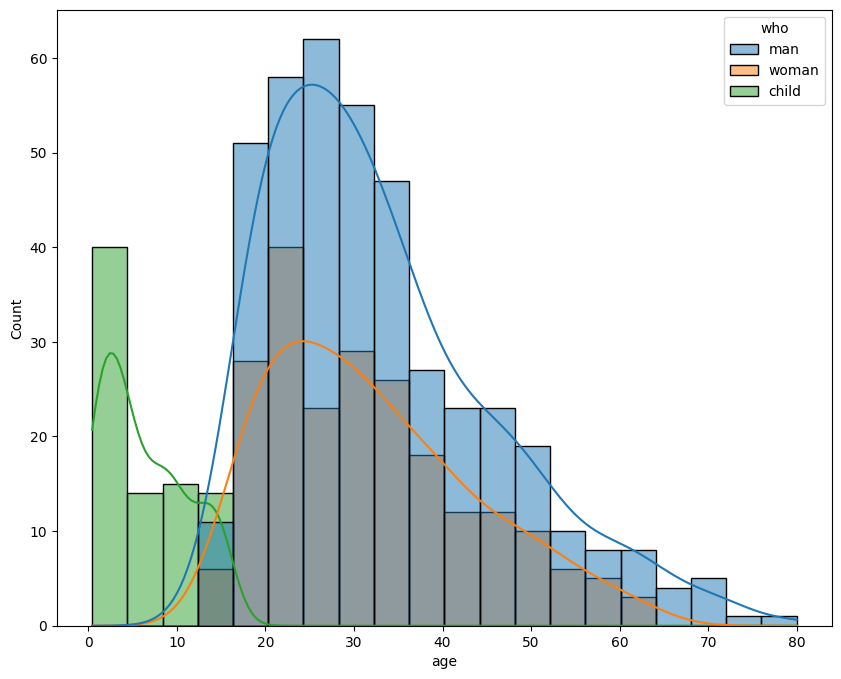

In [17]:
plt.figure(figsize=(10,8))
sns.histplot(data=df, x="age",kde=True,hue="who",color="b")
plt.show()

### **Shapiro-wilk Test For Normal Distribution**

- `Null Hypothesis` : Data is Normally Distributed.
- `Alternative Hypothesis` : Data is Not Normally Distributed.

In [25]:
stastic,p_value = stats.shapiro(df["fare"])

print(f"\nStastic: {stastic}")
print(f"\np_value: {p_value}")

# Decision
if p_value > 0.05:
    print("\nFail to reject H₀: Data is normally distributed.")
else:
    print("\nReject H₀: Data is NOT normally distributed.")


Stastic: 0.5218913010396559

p_value: 1.0840444395829658e-43

Reject H₀: Data is NOT normally distributed.


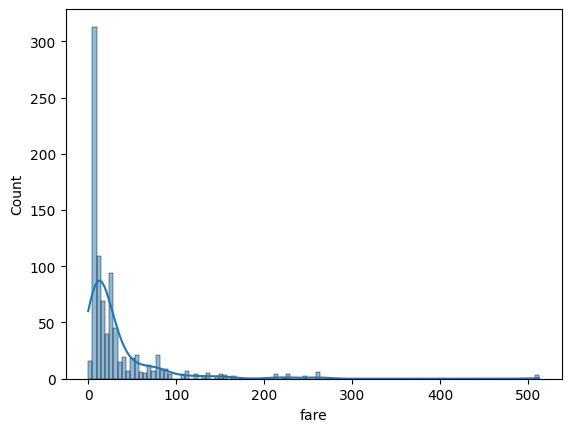

In [23]:
sns.histplot(data=df,x="fare",kde=True)
plt.show()

----